Training samples : (60000, 28, 28)
Testing  samples : (10000, 28, 28)

After pre-processing:
x_train : (60000, 28, 28, 1)  y_train : (60000, 10)
x_test  : (10000, 28, 28, 1)  y_test  : (10000, 10)


Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ C1 (Conv2D)                     │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S2 (AveragePooling2D)           │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C3 (Conv2D)                     │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S4 (AveragePooling2D)           │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C5 (Conv2D)                     │ (None, 1, 1, 120)      │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F6 (Dense)                      │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.9367 - loss: 0.2114 - val_accuracy: 0.9748 - val_loss: 0.0860
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.9773 - loss: 0.0734 - val_accuracy: 0.9828 - val_loss: 0.0594
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 57ms/step - accuracy: 0.9837 - loss: 0.0507 - val_accuracy: 0.9812 - val_loss: 0.0604
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.9881 - loss: 0.0377 - val_accuracy: 0.9845 - val_loss: 0.0578
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.9911 - loss: 0.0279 - val_accuracy: 0.9848 - val_loss: 0.0540
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.9925 - loss: 0.0236 - val_accuracy: 0.9877 - val_loss: 0.0461
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.9938 - loss: 0.0185 - val_accuracy: 0.9857 - val_loss: 0.0539
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.9956 - loss: 0.0145 - 

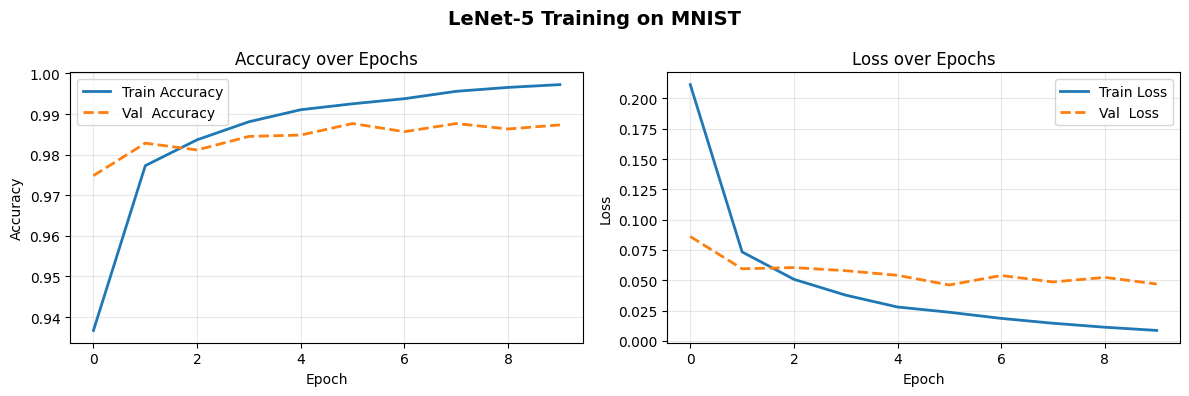

Training history plot saved.


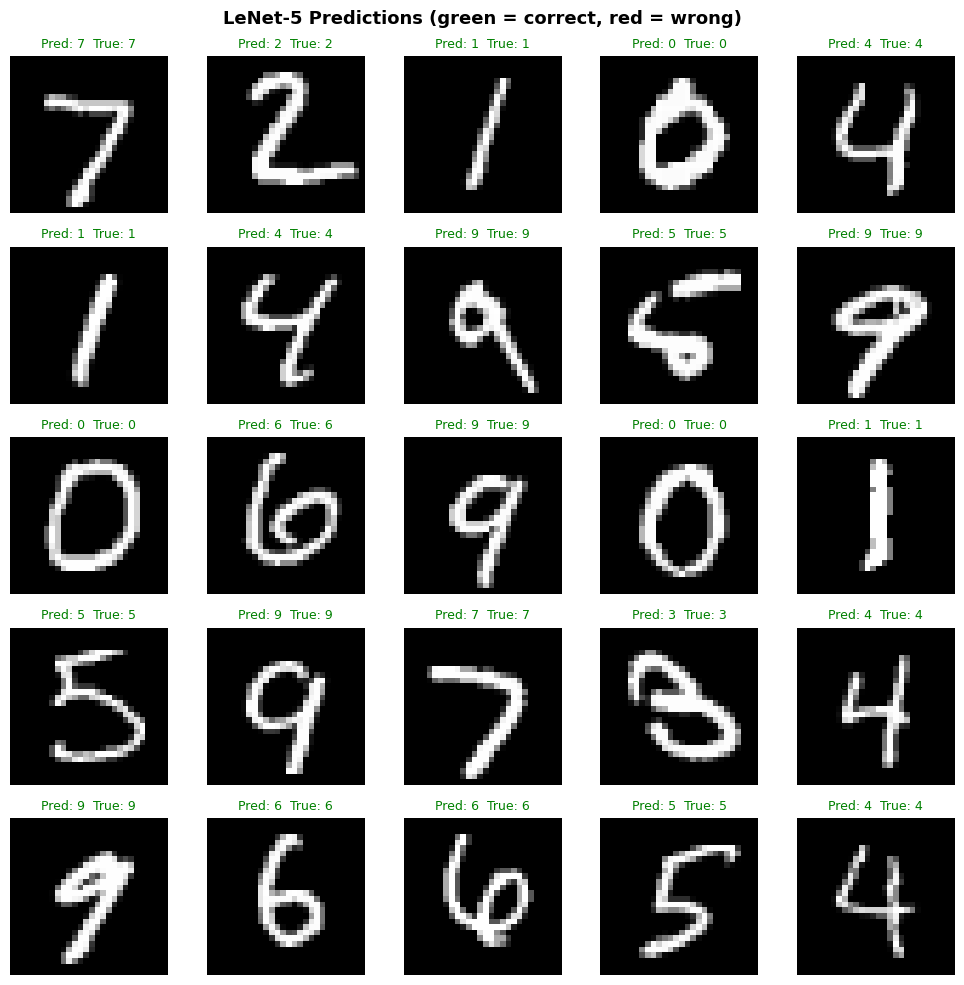

Prediction grid saved.


In [6]:
# =============================================================
#  LeNet-5 on MNIST  –  Keras 3 / TensorFlow 2.16+ compatible
# =============================================================

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (Conv2D, AveragePooling2D,
                                     Flatten, Dense, Input)
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.utils import to_categorical

# ──────────────────────────────────────────────
# 1.  Load & inspect the MNIST dataset
# ──────────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training samples :", x_train.shape)   # (60000, 28, 28)
print("Testing  samples :", x_test.shape)    # (10000, 28, 28)

# ──────────────────────────────────────────────
# 2.  Pre-processing
# ──────────────────────────────────────────────
# (a) Add channel dimension  →  (N, 28, 28, 1)
x_train = x_train[..., np.newaxis]
x_test  = x_test [..., np.newaxis]

# (b) Normalise pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test .astype("float32") / 255.0

# (c) One-hot encode labels  →  (N, 10)
y_train = to_categorical(y_train, num_classes=10)
y_test  = to_categorical(y_test,  num_classes=10)

print("\nAfter pre-processing:")
print("x_train :", x_train.shape, " y_train :", y_train.shape)
print("x_test  :", x_test.shape,  " y_test  :", y_test.shape)

# ──────────────────────────────────────────────
# 3.  Build LeNet-5
# ──────────────────────────────────────────────
#   Original paper used 32×32 input; MNIST is 28×28.
#   We keep 28×28 and adjust accordingly.
#
#   Layer stack
#   ───────────
#   Input      28×28×1
#   C1  Conv   6 filters 5×5, stride 1  → 24×24×6
#   S2  Pool   AvgPool 2×2, stride 2    → 12×12×6
#   C3  Conv  16 filters 5×5, stride 1  →  8×8×16
#   S4  Pool   AvgPool 2×2, stride 2    →  4×4×16
#   C5  Conv  120 filters 4×4, stride 1 →  1×1×120  (= FC)
#   Flatten                              →  120
#   F6  Dense 84                        →  84
#   Out Dense 10 + softmax              →  10

def build_lenet(input_shape=(28, 28, 1), num_classes=10):
    # Learning-rate schedule (replaces deprecated `decay` argument)
    lr_schedule = ExponentialDecay(
        initial_learning_rate=0.1,
        decay_steps=10_000,
        decay_rate=0.96,
        staircase=False
    )

    model = Sequential([
        Input(shape=input_shape),

        # C1 – first convolutional layer
        Conv2D(filters=6, kernel_size=5, strides=1,
               padding='valid', activation='tanh',
               name='C1'),

        # S2 – average pooling (subsampling)
        AveragePooling2D(pool_size=2, strides=2, name='S2'),

        # C3 – second convolutional layer
        Conv2D(filters=16, kernel_size=5, strides=1,
               padding='valid', activation='tanh',
               name='C3'),

        # S4 – average pooling (subsampling)
        AveragePooling2D(pool_size=2, strides=2, name='S4'),

        # C5 – acts as a fully-connected conv layer
        Conv2D(filters=120, kernel_size=4, strides=1,
               padding='valid', activation='tanh',
               name='C5'),

        Flatten(),

        # F6 – fully connected
        Dense(84, activation='tanh', name='F6'),

        # Output
        Dense(num_classes, activation='softmax', name='Output'),
    ], name='LeNet-5')

    model.compile(
        loss='categorical_crossentropy',
        optimizer=SGD(learning_rate=lr_schedule,
                      momentum=0.9,
                      nesterov=True),
        metrics=['accuracy']
    )
    return model


lenet = build_lenet()
lenet.summary()

# ──────────────────────────────────────────────
# 4.  Train
# ──────────────────────────────────────────────
EPOCHS     = 10
BATCH_SIZE = 128

history = lenet.fit(
    x_train, y_train,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_split= 0.1,      # 10 % of training data for validation
    verbose         = 1
)

# ──────────────────────────────────────────────
# 5.  Evaluate on test set
# ──────────────────────────────────────────────
test_loss, test_acc = lenet.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.2f}%")

# ──────────────────────────────────────────────
# 6.  Visualise training history
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("LeNet-5 Training on MNIST", fontsize=14, fontweight='bold')

# --- Accuracy ---
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val  Accuracy',  linewidth=2,
             linestyle='--')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Loss ---
axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val  Loss',  linewidth=2,
             linestyle='--')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lenet5_training_history.png', dpi=150)
plt.show()
print("Training history plot saved.")

# ──────────────────────────────────────────────
# 7.  Visualise sample predictions
# ──────────────────────────────────────────────
predictions = lenet.predict(x_test[:25], verbose=0)
pred_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test[:25],  axis=1)

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
fig.suptitle("LeNet-5 Predictions (green = correct, red = wrong)",
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i].squeeze(), cmap='gray')
    color = 'green' if pred_labels[i] == true_labels[i] else 'red'
    ax.set_title(f"Pred: {pred_labels[i]}  True: {true_labels[i]}",
                 color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('lenet5_predictions.png', dpi=150)
plt.show()
print("Prediction grid saved.")